In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline

# Bypass Hugging Face token jika ada isu otentikasi di sistem
os.environ.pop("HF_TOKEN", None)
os.environ.pop("HF_API_TOKEN", None)

print("Library berhasil dimuat!")


Library berhasil dimuat!


In [2]:
# Membaca data hasil scraping
df = pd.read_csv('comment_data.csv')

# Fungsi pembersihan komentar
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]+>', ' ', text)  # Hapus tag HTML
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Hapus URL
    text = re.sub(r'@\w+', '', text)      # Hapus mention @username
    text = re.sub(r'\s+', ' ', text).strip() # Hapus spasi berlebih
    return text

df['Cleaned Comment'] = df['Comment'].apply(clean_text)
print(f"Total komentar yang dibaca: {len(df)}")
df.head() # Menampilkan 5 baris pertama data


Total komentar yang dibaca: 5035


,Comment ID,Comment Link,Commenter Name,Commenter ID,Comment,Likes,Cleaned Comment
0,UgwL0FwToKzMOJO8s9F4AaABAg,https://www.youtube.com/watch?v=SVI8xheP-j4&lc...,@astronacciinternational,UCYRFEuGLfXFFvbq2-nStY9w,Bagaimana pendapat kamu tentang MBG? Tulis pan...,250,Bagaimana pendapat kamu tentang MBG? Tulis pan...
1,UgzE6FRFOZRGBw57lHN4AaABAg,https://www.youtube.com/watch?v=SVI8xheP-j4&lc...,@tanamalttoni7972,UCVotoc_AE3x1cXbphWMUPqA,"Siapa bilang 15 atau 13 teori doang, 8000 iya",0,"Siapa bilang 15 atau 13 teori doang, 8000 iya"
2,UgzIp9X3g6YiGppqX3h4AaABAg,https://www.youtube.com/watch?v=SVI8xheP-j4&lc...,@tanamalttoni7972,UCVotoc_AE3x1cXbphWMUPqA,"Maksut gw apa yg d omongin, tp klu dah terlanj...",0,"Maksut gw apa yg d omongin, tp klu dah terlanj..."
3,Ugy3Vln3L5a8ZVPaQSB4AaABAg,https://www.youtube.com/watch?v=SVI8xheP-j4&lc...,@Kartonokartono-g3d,UCoqYflPyUtSyp1PvrW5QJeA,"Rakyat tidak butuh rincian dari penjilat MBG ,...",0,"Rakyat tidak butuh rincian dari penjilat MBG ,..."
4,UgzKrnHFL9ZiA8BEmuN4AaABAg,https://www.youtube.com/watch?v=SVI8xheP-j4&lc...,@isgianto854,UCwlWoUmcya-n9I2GZ6bew4w,Program mulia sodakoh Ama rakyat buat sangu di...,0,Program mulia sodakoh Ama rakyat buat sangu di...


In [3]:
print("Memuat model sentiment analysis (w11wo)...")
classifier = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier",
    device=-1, # -1 berarti menggunakan CPU
    token=False
)
print("Model berhasil dimuat!")


Memuat model sentiment analysis (w11wo)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model berhasil dimuat!


In [4]:
# Ganti komentar kosong/netral agar tidak error
texts_to_predict = [txt if txt else "netral" for txt in df['Cleaned Comment'].tolist()]

sentiments = []
scores = []
batch_size = 32
total_comments = len(texts_to_predict)

# Menjalankan prediksi dalam batch
for i in range(0, total_comments, batch_size):
    batch_texts = texts_to_predict[i:i+batch_size]
    batch_results = classifier(batch_texts, truncation=True, max_length=512)
    
    # Mapping label model w11wo ke bentuk standard
    label_map = {'positif': 'positive', 'netral': 'neutral', 'negatif': 'negative'}
    
    for res in batch_results:
        raw_label = res['label'].lower()
        sentiments.append(label_map.get(raw_label, raw_label))
        scores.append(res['score'])
        
    if (i + batch_size) % 320 == 0 or (i + batch_size) >= total_comments:
        print(f"Diproses: {min(i + batch_size, total_comments)}/{total_comments} komentar...")

df['Sentiment'] = sentiments
df['Confidence Score'] = scores

# Simpan hasilnya ke CSV baru
df.to_csv('comment_sentiment.csv', index=False, encoding='utf-8')
print("Selesai! Hasil disimpan di 'comment_sentiment.csv'")


Diproses: 320/5035 komentar...
Diproses: 640/5035 komentar...
Diproses: 960/5035 komentar...
Diproses: 1280/5035 komentar...
Diproses: 1600/5035 komentar...
Diproses: 1920/5035 komentar...
Diproses: 2240/5035 komentar...
Diproses: 2560/5035 komentar...
Diproses: 2880/5035 komentar...
Diproses: 3200/5035 komentar...
Diproses: 3520/5035 komentar...
Diproses: 3840/5035 komentar...
Diproses: 4160/5035 komentar...
Diproses: 4480/5035 komentar...
Diproses: 4800/5035 komentar...
Diproses: 5035/5035 komentar...
Selesai! Hasil disimpan di 'comment_sentiment.csv'


Sentiment
negative    3473
positive    1137
neutral      425
Name: count, dtype: int64


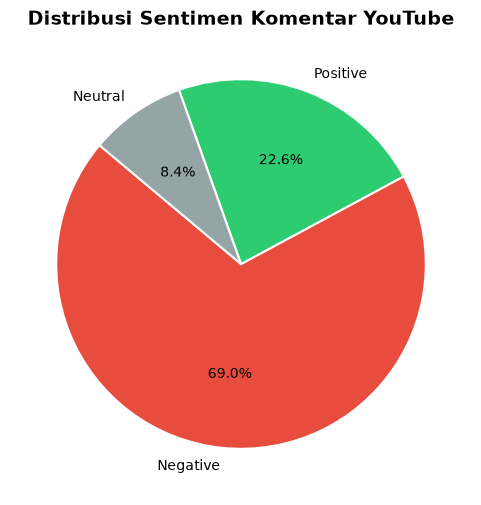

In [5]:
sentiment_counts = df['Sentiment'].value_counts()
print(sentiment_counts)

# Tentukan warna representatif
colors = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}
plot_colors = [colors.get(sent, '#3498db') for sent in sentiment_counts.index]

plt.figure(figsize=(6, 6))
plt.pie(
    sentiment_counts, 
    labels=[s.capitalize() for s in sentiment_counts.index], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plot_colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Distribusi Sentimen Komentar YouTube', fontsize=14, fontweight='bold')
plt.show()


In [6]:
print("--- CONTOH KOMENTAR POSITIF ---")
pos_samples = df[df['Sentiment'] == 'positive']['Comment'].head(5)
for idx, comment in enumerate(pos_samples, 1):
    print(f"{idx}. {comment}\n")

print("--- CONTOH KOMENTAR NEGATIF ---")
neg_samples = df[df['Sentiment'] == 'negative']['Comment'].head(5)
for idx, comment in enumerate(neg_samples, 1):
    print(f"{idx}. {comment}\n")


--- CONTOH KOMENTAR POSITIF ---
1. Sangat setuju pak gema 👍🏼👍🏼👍🏼

2. Makanan di luar negri setengah matang di Konoha setengah matang GK masuk di lidah

3. Saya petani asli...merasakan betul manfaat program mbg.  Sekarang mbg stop sementara mulai harga buah2an spt semangka dan sayur mayur mulai turun. Kalau sebulan saja stop maka pasti harga komoditas pertanian dan ikan akan turun bebas. Kalau mau di ganti uang..maka uang akan berputar2 ke kalangan atas. Baru kali ini para petani dan nelayan merasa di bela oleh pemerintah.

4. Mantap benar maju terus mbg sip otak yg jeius  kipra yg benar mantap

5. Dari segi apapun pendapat saya MBG itu wajib dipertahankan,

--- CONTOH KOMENTAR NEGATIF ---
1. Siapa bilang 15 atau 13 teori doang, 8000 iya

2. Maksut gw apa yg d omongin, tp klu dah terlanjur gini gmn penyelesainnya .. tutup aja lbh bagus

3. Rakyat tidak butuh rincian dari penjilat MBG , hentikan MBG hargaati dan Prabowo Gibran turun.

4. Program mulia sodakoh Ama rakyat buat sangu di akh